In [ ]:
# pip install matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path_horas = r"H:\Python\3° Etapa\Analise dados\atividade2\Tabela 1.1.1.xls"
bruto_1 = pd.read_excel(path_horas, engine="xlrd", header=None)

indicador_1 = bruto_1.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

In [ ]:
path_formacao = r"H:\Python\3° Etapa\Analise dados\atividade3\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"
bruto = pd.read_excel(path_formacao, sheet_name="Sheet1", header=None)

formacao_total = bruto.iloc[3:36, 0:4].copy()
formacao_total.columns = ["regiao", "total", "homens", "mulheres"]
formacao_total = formacao_total.reset_index(drop=True)
for col in formacao_total.columns[1:]:
    formacao_total[col] = pd.to_numeric(formacao_total[col], errors="coerce")
formacao_total = formacao_total.rename(columns={"regiao": "uf_regiao", "homens": "total_homens", "mulheres": "total_mulheres"})

formacao_stem = bruto.iloc[3:36, [0] + list(range(4, 7))].copy()
formacao_stem.columns = ["regiao", "total", "homens", "mulheres"]
formacao_stem = formacao_stem.reset_index(drop=True)
for col in formacao_stem.columns[1:]:
    formacao_stem[col] = pd.to_numeric(formacao_stem[col], errors="coerce")
formacao_stem = formacao_stem.rename(columns={"regiao": "uf_regiao"})

formacao_saude = bruto.iloc[3:36, [0] + list(range(7, 10))].copy()
formacao_saude.columns = ["regiao", "total", "homens", "mulheres"]
formacao_saude = formacao_saude.reset_index(drop=True)
for col in formacao_saude.columns[1:]:
    formacao_saude[col] = pd.to_numeric(formacao_saude[col], errors="coerce")
formacao_saude = formacao_saude.rename(columns={"regiao": "uf_regiao"})

In [ ]:
caminho = r"H:\Python\3° Etapa\Analise dados\atividade4\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"
df = pd.read_excel(caminho, header=2)
df = df.drop(columns=["Unnamed: 0"])
df.columns = ["UF", "COD_UF", "COD_MUNIC", "NOME_MUNICIPIO", "POP_2010_SINOPSE", "POP_2010_COMPAT", "POP_2022"]

pop_estados = df.groupby("UF")[["POP_2010_COMPAT", "POP_2022"]].sum().reset_index()
pop_estados["CRESCIMENTO"] = pop_estados["POP_2022"] - pop_estados["POP_2010_COMPAT"]
pop_estados = pop_estados.sort_values("CRESCIMENTO", ascending=False)
pop_estados = pop_estados[~pop_estados["UF"].str.contains("Fonte|Nota", na=False)]

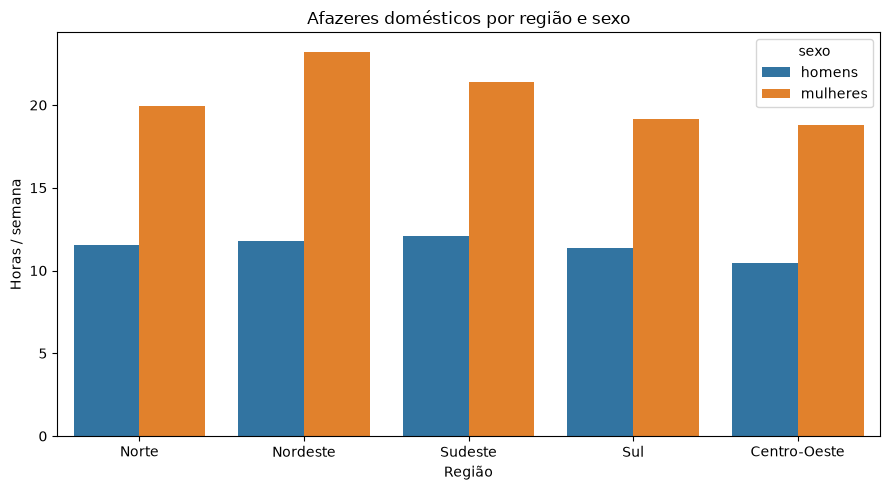

In [ ]:
# Atividade 2 (HORAS QUE MULHERES TRABALHAM EM SERVIÇOS DOMÉSTICOS)
# Barras agrupadas: homens x mulheres por grande região
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)
ax.set_title("Afazeres domésticos por região e sexo")
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")
plt.tight_layout()
plt.show()

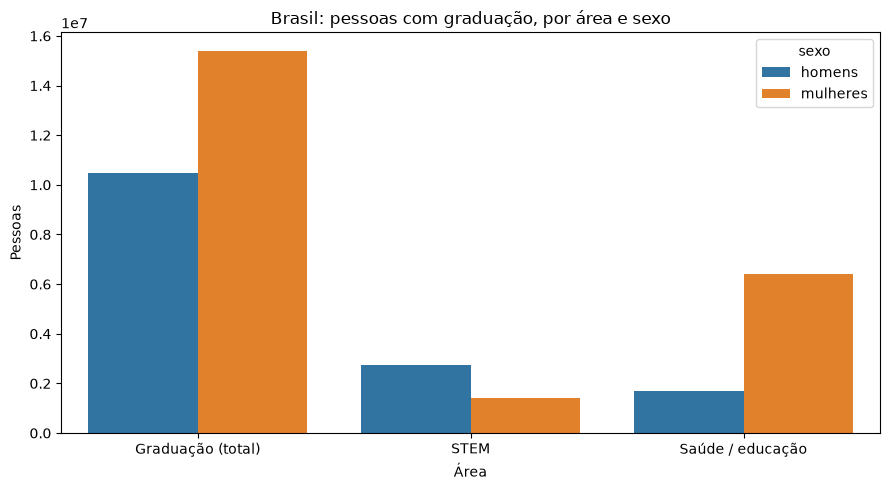

In [ ]:
# ATIVIDADE 3 (FORMAÇÃO ACADÊMICA)

# TOTAL É FORMAÇÃO TOTAL
# STEM É A MINHA FORMAÇÃO DE MATEMÁTICA
# SAUDE É MINHA TAB DE FORMAÇÃO EDUCAÇÃO E SAÚDE

# Barras agrupadas: homens x mulheres no Brasil (três recortes)
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / educação"],
        "homens": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_homens"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "homens"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "homens"].item(),
        ],
        "mulheres": [
            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_mulheres"].item(),
            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "mulheres"].item(),
            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "mulheres"].item(),
        ],
    }
)
brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")
plt.tight_layout()
plt.show()

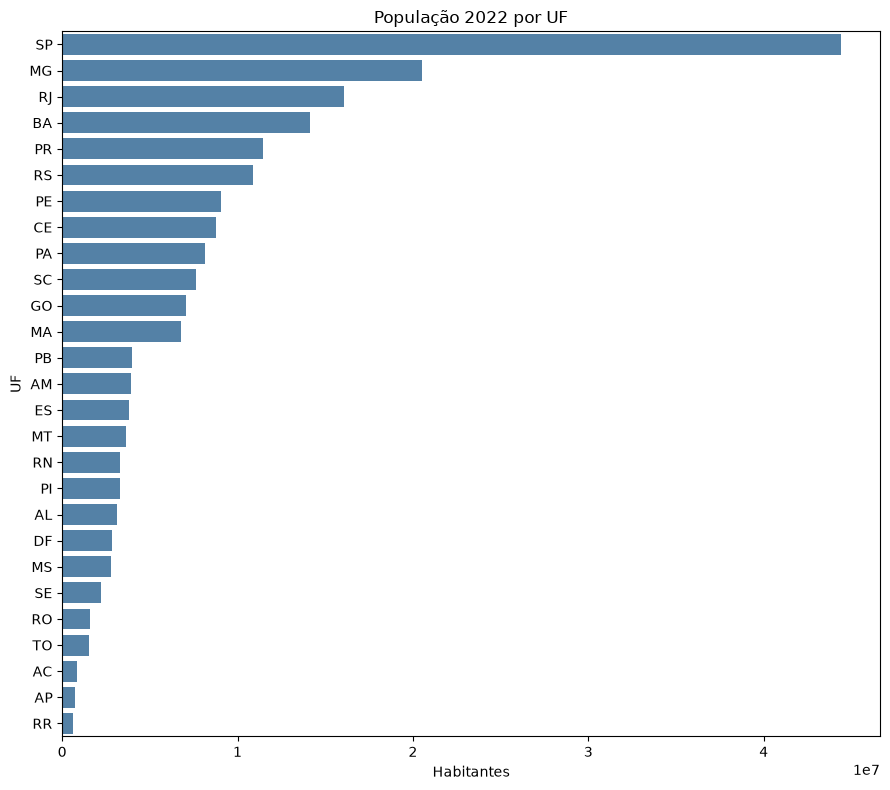

In [ ]:
# ATIVIDADE 4
# Barras: população 2022 por UF
fig, ax = plt.subplots(figsize=(9, 8))
ordem = pop_estados.sort_values("POP_2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="POP_2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()